In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize


### Conclusion

In this cell, all the required Python libraries were imported successfully.
These libraries will be used for data loading, preprocessing,
handling missing values, statistical analysis, data visualization,
and outlier treatment throughout the project.

# PART A - Handling Missing Value

In [ ]:
df = pd.read_csv("dataset.csv")
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,NaN,Male,East,20.130781,128.027122,180.251293,127.843280,0
1,P0002,69.0,Male,North,23.071813,131.390819,188.227113,NaN,0
2,P0003,46.0,Female,East,19.409927,140.418152,206.523900,117.925679,0
3,P0004,32.0,Male,North,24.619020,105.075002,174.682976,100.423363,0
4,P0005,60.0,Male,East,NaN,127.889663,149.921320,98.678900,0


### Conclusion

The dataset was loaded successfully.
The first five rows were displayed to understand the data.

In [28]:
df.shape

(1000, 9)

### Conclusion

The dataset contains a specific number of rows and columns.
This gives the overall size of the dataset.

In [29]:
df.isnull().sum()

patient_id         0
age               80
gender            80
region            80
bmi               80
blood_pressure     0
cholesterol       80
glucose           80
disease_risk       0
dtype: int64

### Conclusion

The missing values in each column were checked.
This helps identify which columns need data cleaning.

In [30]:
missing_percent = (df.isnull().sum()/len(df))*100
print(missing_percent)

patient_id        0.0
age               8.0
gender            8.0
region            8.0
bmi               8.0
blood_pressure    0.0
cholesterol       8.0
glucose           8.0
disease_risk      0.0
dtype: float64


### Conclusion

The percentage of missing values was calculated for each column.
This helps decide how to handle missing data.

In [ ]:
# Missing values check
print("Before")
print(df["bmi"].isnull().sum())

# Mean Imputation
num_imputer = SimpleImputer(strategy="mean")
df["bmi"] = num_imputer.fit_transform(df[["bmi"]])

print("\nAfter")
print(df["bmi"].isnull().sum())

Before
80

After
0


### Conclusion

The missing values in the `bmi` column were filled using the mean value.
After imputation, no missing values remained in the column.

In [32]:
df_median = df.copy()

# Missing values check
print("Before")
print(df_median["bmi"].isnull().sum())

# Median Imputation
bmi_imputer = SimpleImputer(strategy="median")
df_median["bmi"] = bmi_imputer.fit_transform(df_median[["bmi"]])

print("\nAfter")
print(df_median["bmi"].isnull().sum())

Before
0

After
0


### Conclusion

The missing values in the `bmi` column were filled using the median value.
After imputation, the column had no missing values.

In [33]:
# Missing values check
print("Before")
print(df["region"].isnull().sum())

# Median Imputation
region_imputer = SimpleImputer(strategy="most_frequent")
df["region"] = region_imputer.fit_transform(df[["region"]]).ravel()

print("\nAfter")
print(df["region"].isnull().sum())

Before
80

After
0


### Conclusion

The missing values in the `region` column were filled using the most frequent value.
After imputation, no missing values remained.

In [34]:
# Missing values check
print("Before")
print(df["gender"].isnull().sum())

# Median Imputation
gender_imputer = SimpleImputer(strategy="most_frequent")
df["gender"] = gender_imputer.fit_transform(df[["gender"]]).ravel()

print("\nAfter")
print(df["gender"].isnull().sum())

Before
80

After
0


### Conclusion

The missing values in the `gender` column were filled using the most frequent value.
The column now has no missing values.

In [35]:
df["cholesterol_missing"] = df["cholesterol"].isnull().astype(int)

random_sample = df["cholesterol"].dropna().sample(
    df["cholesterol"].isnull().sum(),
    random_state=42
)

df.loc[df["cholesterol"].isnull(), "cholesterol"] = random_sample.values

print(df["cholesterol"].isnull().sum())

0


### Conclusion

The missing values in the `cholesterol` column were filled using random sample imputation.
A new column was created to mark the original missing values.

In [ ]:
# Apply MICE

mice = IterativeImputer(random_state=42)

df[["glucose"]] = mice.fit_transform(
    df[["glucose"]]
)

print(df["glucose"].isnull().sum())

0


### Conclusion

The missing values in the `glucose` column were filled using the MICE method.
The column now has no missing values.

In [ ]:
knn = KNNImputer(n_neighbors=3)
df[["age"]] = knn.fit_transform(df[["age"]])

print(df[["age"]].isnull().sum())

age    0
dtype: int64


### Conclusion

The missing values in the `age` column were filled using the KNN method.
The column now has no missing values.

In [38]:
df.isnull().sum()

patient_id             0
age                    0
gender                 0
region                 0
bmi                    0
blood_pressure         0
cholesterol            0
glucose                0
disease_risk           0
cholesterol_missing    0
dtype: int64

### Conclusion

The dataset was checked again for missing values.
This confirms whether all missing values have been handled.

# PART B - Handling Outliers

In [39]:
print("Shape Before:", df.shape)
df.describe()

Shape Before: (1000, 10)


,age,bmi,blood_pressure,cholesterol,glucose,disease_risk,cholesterol_missing
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.770652,26.275614,125.320519,199.512617,99.669443,0.506000,0.080000
std,17.456900,6.562789,26.851492,29.413642,18.743989,0.500214,0.271429
min,18.000000,11.446288,75.703873,102.816868,25.824068,0.000000,0.000000
25%,36.000000,22.682822,110.603500,180.541632,87.934853,0.000000,0.000000
50%,49.770652,25.925163,121.732387,199.165174,99.669443,1.000000,0.000000
75%,65.000000,28.145241,132.471571,220.467830,111.417896,1.000000,0.000000
max,79.000000,70.349343,268.148857,309.731054,155.322798,1.000000,1.000000


### Conclusion

The dataset shape and statistical summary were checked.
This helps understand the overall data before further analysis.

In [40]:
df.describe()

,age,bmi,blood_pressure,cholesterol,glucose,disease_risk,cholesterol_missing
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.770652,26.275614,125.320519,199.512617,99.669443,0.506000,0.080000
std,17.456900,6.562789,26.851492,29.413642,18.743989,0.500214,0.271429
min,18.000000,11.446288,75.703873,102.816868,25.824068,0.000000,0.000000
25%,36.000000,22.682822,110.603500,180.541632,87.934853,0.000000,0.000000
50%,49.770652,25.925163,121.732387,199.165174,99.669443,1.000000,0.000000
75%,65.000000,28.145241,132.471571,220.467830,111.417896,1.000000,0.000000
max,79.000000,70.349343,268.148857,309.731054,155.322798,1.000000,1.000000


### Conclusion

The statistical summary of the numerical data was displayed.
This helps understand the distribution of the data.

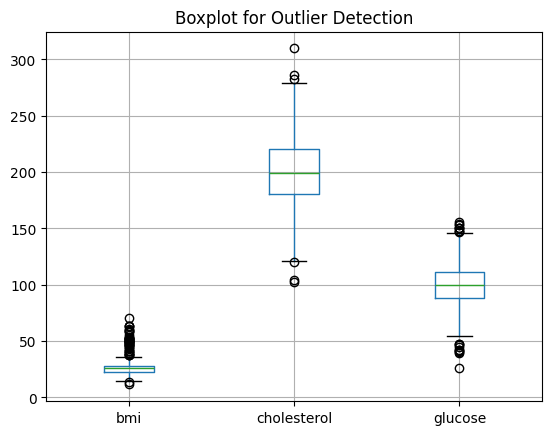

In [ ]:
df[["bmi","cholesterol","glucose"]].boxplot()
plt.title("Boxplot for Outlier Detection")
plt.show()

### Conclusion

A boxplot was created to detect outliers.
It helps identify unusual values in the data.

In [45]:
Dataframe = df.copy()

mean = Dataframe["cholesterol"].mean()
std = Dataframe["cholesterol"].std()

Dataframe["z_score"] = (Dataframe["cholesterol"] - mean) / std

Dataframe[["cholesterol", "z_score"]]

outliers = Dataframe[(Dataframe["z_score"] > 3) | (Dataframe["z_score"] < -3)]

print("Total Outliers:", len(outliers))

Dataframe = Dataframe[(Dataframe["z_score"] >= -3) & (Dataframe["z_score"] <= 3)]

print("Dataset Shape After Removing Outliers:", Dataframe.shape)

Total Outliers: 3
Dataset Shape After Removing Outliers: (997, 11)


### Conclusion

Outliers were detected using the Z-Score method.
The detected outliers were removed from the dataset.

In [46]:
mean = Dataframe["glucose"].mean()
std = Dataframe["glucose"].std()

Dataframe["z_score"] = (Dataframe["glucose"] - mean) / std

Dataframe[["glucose", "z_score"]]

outliers = Dataframe[(Dataframe["z_score"] > 3) | (Dataframe["z_score"] < -3)]

print("Total Outliers:", len(outliers))

Dataframe = Dataframe[(Dataframe["z_score"] >= -3) & (Dataframe["z_score"] <= 3)]

print("Dataset Shape After Removing Outliers:", Dataframe.shape)

Total Outliers: 6
Dataset Shape After Removing Outliers: (991, 11)


### Conclusion

Outliers in the `glucose` column were detected using the Z-Score method.
The detected outliers were removed from the dataset.

In [49]:
Q1 = Dataframe["bmi"].quantile(0.25)
Q3 = Dataframe["bmi"].quantile(0.75)

IQR = Q3 - Q1

Lower_Limit = Q1 - 1.5 * IQR
Upper_Limit = Q3 + 1.5 * IQR

print("Lower Limit:", Lower_Limit)
print("Upper Limit:", Upper_Limit)

outliers = Dataframe[(Dataframe["bmi"] < Lower_Limit) | (Dataframe["bmi"] > Upper_Limit)]

print("Total Outliers:", len(outliers))

Dataframe = Dataframe[(Dataframe["bmi"] >= Lower_Limit) & (Dataframe["bmi"] <= Upper_Limit)]

print("Dataset Shape After Removing Outliers:", Dataframe.shape)

Lower Limit: 14.480994189104866
Upper Limit: 36.345196146684614
Total Outliers: 47
Dataset Shape After Removing Outliers: (944, 11)


### Conclusion

Outliers in the `bmi` column were detected using the IQR method.
The detected outliers were removed from the dataset.

In [51]:
Lower_Limit = Dataframe["glucose"].quantile(0.01)
Upper_Limit = Dataframe["glucose"].quantile(0.99)

print("Lower Limit:", Lower_Limit)
print("Upper Limit:", Upper_Limit)

outliers = Dataframe[(Dataframe["glucose"] < Lower_Limit) | (Dataframe["glucose"] > Upper_Limit)]

print("Total Outliers:", len(outliers))

Dataframe["glucose"] = Dataframe["glucose"].clip(Lower_Limit, Upper_Limit)

print("Dataset Shape After Handling Outliers:", Dataframe.shape)

Lower Limit: 57.76215198750764
Upper Limit: 144.9403118505042
Total Outliers: 20
Dataset Shape After Handling Outliers: (944, 11)


### Conclusion

Outliers in the `glucose` column were handled using the percentile method.
The values were limited within the defined range.

In [ ]:

df["blood_pressure"] = winsorize(
    df["blood_pressure"],
    limits=[0.01, 0.01]
)

print("Winsorization Applied Successfully")

Winsorization Applied Successfully


(1000, 10)

### Conclusion

Winsorization was applied to the `blood_pressure` column.
This reduced the effect of extreme values.

In [54]:
print("Original Dataset Shape :", df.shape)
print("Processed Dataset Shape:", Dataframe.shape)

print("\nSummary Before Treatment")
print(df.describe())

print("\nSummary After Treatment")
print(Dataframe.describe())

Original Dataset Shape : (1000, 10)
Processed Dataset Shape: (944, 11)

Summary Before Treatment
               age          bmi  blood_pressure  cholesterol      glucose  \
count  1000.000000  1000.000000     1000.000000  1000.000000  1000.000000   
mean     49.770652    26.275614      125.272893   199.512617    99.669443   
std      17.456900     6.562789       26.255094    29.413642    18.743989   
min      18.000000    11.446288       84.933677   102.816868    25.824068   
25%      36.000000    22.682822      110.603500   180.541632    87.934853   
50%      49.770652    25.925163      121.732387   199.165174    99.669443   
75%      65.000000    28.145241      132.471571   220.467830   111.417896   
max      79.000000    70.349343      243.967877   309.731054   155.322798   

       disease_risk  cholesterol_missing  
count   1000.000000          1000.000000  
mean       0.506000             0.080000  
std        0.500214             0.271429  
min        0.000000             0.000

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


### Conclusion

The original and processed datasets were compared.
The summary shows the changes after data treatment.

# PART C - Final Clean Dataset

In [55]:
print("Final Dataset Shape:", df.shape)

df.head()

Final Dataset Shape: (1000, 10)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,cholesterol_missing
0,P0001,49.770652,Male,East,20.130781,128.027122,180.251293,127.843280,0,0
1,P0002,69.000000,Male,North,23.071813,131.390819,188.227113,99.669443,0,0
2,P0003,46.000000,Female,East,19.409927,140.418152,206.523900,117.925679,0,0
3,P0004,32.000000,Male,North,24.619020,105.075002,174.682976,100.423363,0,0
4,P0005,60.000000,Male,East,26.275614,127.889663,149.921320,98.678900,0,0


### Conclusion

The final dataset shape was checked.
The first five rows were displayed to verify the processed data.

In [56]:
df.isnull().sum()

patient_id             0
age                    0
gender                 0
region                 0
bmi                    0
blood_pressure         0
cholesterol            0
glucose                0
disease_risk           0
cholesterol_missing    0
dtype: int64

### Conclusion

The final dataset was checked for missing values.
This confirms that the data is complete.

In [57]:
df.describe()

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,age,bmi,blood_pressure,cholesterol,glucose,disease_risk,cholesterol_missing
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.770652,26.275614,125.272893,199.512617,99.669443,0.506000,0.080000
std,17.456900,6.562789,26.255094,29.413642,18.743989,0.500214,0.271429
min,18.000000,11.446288,84.933677,102.816868,25.824068,0.000000,0.000000
25%,36.000000,22.682822,110.603500,180.541632,87.934853,0.000000,0.000000
50%,49.770652,25.925163,121.732387,199.165174,99.669443,1.000000,0.000000
75%,65.000000,28.145241,132.471571,220.467830,111.417896,1.000000,0.000000
max,79.000000,70.349343,243.967877,309.731054,155.322798,1.000000,1.000000


### Conclusion

The statistical summary of the final dataset was displayed.
This provides an overview of the cleaned data.

### 1. Which imputation strategy was most effective?

Answer: KNN Imputer was the most effective because it filled missing values using similar records, which helped preserve the original data pattern.

### 2. Which outlier handling method preserved data quality best?

Answer: Winsorization preserved data quality best because it capped extreme values instead of removing records, keeping all observations in the dataset.

### 3. How did data cleaning improve dataset usability?

Answer: Data cleaning removed missing values and handled outliers, making the dataset cleaner, more accurate, and ready for machine learning and data analysis.